## Import Liblary

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)
print("Semua library berhasil di-import!")

TensorFlow Version: 2.20.0
Semua library berhasil di-import!


## Upload Datasets

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/Dataset Brain Tumor'
print("Isi folder dataset:", os.listdir(DATASET_PATH))

Mounted at /content/drive
Isi folder dataset: ['yes', 'no']


In [3]:
# Cek jumlah gambar di folder luar
print("Jumlah gambar YES di luar:", len(os.listdir('/content/drive/MyDrive/Dataset Brain Tumor/yes')))
print("Jumlah gambar NO di luar:", len(os.listdir('/content/drive/MyDrive/Dataset Brain Tumor/no')))

# Cek isi dari folder yang bernama 'brain_tumor_dataset'
# print("Isi di dalam folder 'brain_tumor_dataset':", os.listdir('/content/drive/MyDrive/Dataset Brain Tumor/brain_tumor_dataset')) # This line caused an error as the folder was removed.

Jumlah gambar YES di luar: 155
Jumlah gambar NO di luar: 98


## Data Cliening

In [4]:
import shutil
import os

# Definisikan jalur folder pengganggu
path_pengganggu = '/content/drive/MyDrive/Dataset Brain Tumor/brain_tumor_dataset'

# Proses penghapusan
if os.path.exists(path_pengganggu):
    shutil.rmtree(path_pengganggu)
    print("Folder duplikat 'brain_tumor_dataset' berhasil dihapus!")
else:
    print("Folder sudah tidak ada atau sudah dihapus sebelumnya.")

# Cek ulang isi folder utama, sekarang HARUSNYA hanya muncul: ['yes', 'no']
DATASET_PATH = '/content/drive/MyDrive/Dataset Brain Tumor'
print("Isi folder dataset sekarang:", os.listdir(DATASET_PATH))

Folder sudah tidak ada atau sudah dihapus sebelumnya.
Isi folder dataset sekarang: ['yes', 'no']


#Muat Gambar ke TensorFlow (ImageDataGenerator)
Setelah memastikan output di atas hanya memunculkan ['yes', 'no'], sekarang jalankan kode di bawah ini untuk membagi data secara otomatis menjadi 80% untuk Training (Belajar) dan 20% untuk Validation (Ujian).

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Normalisasi warna gambar (0-255 jadi 0-1) dan bagi data (split 20%)
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

print("--- Memuat Data Training (80%) ---")
train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(150, 150),   # Mengubah ukuran semua gambar MRI menjadi 150x150 pixel
    batch_size=32,
    class_mode='binary',       # Karena hanya ada 2 kelas (yes / no)
    subset='training',
    shuffle=True
)

print("\n--- Memuat Data Validasi (20%) ---")
val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

--- Memuat Data Training (80%) ---
Found 203 images belonging to 2 classes.

--- Memuat Data Validasi (20%) ---
Found 50 images belonging to 2 classes.


In [6]:
print(f"Total Training  : {train_generator.samples} gambar")
print(f"Total Validasi  : {val_generator.samples} gambar")
print(f"Total Keseluruhan: {train_generator.samples + val_generator.samples} gambar")
print(f"Kelas           : {train_generator.class_indices}")

Total Training  : 203 gambar
Total Validasi  : 50 gambar
Total Keseluruhan: 253 gambar
Kelas           : {'no': 0, 'yes': 1}


# Membangun arsitektur CNN

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,      # Mengacak rotasi gambar
    width_shift_range=0.2,  # Menggeser posisi gambar secara horizontal
    height_shift_range=0.2, # Menggeser posisi gambar secara vertikal
    shear_range=0.2,        # Memberikan efek miring
    zoom_range=0.2,         # Melakukan zoom secara acak
    horizontal_flip=True,   # Membalik gambar secara horizontal
    fill_mode='nearest'     # Mengisi area kosong saat gambar digeser/diputar
)

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False # Kunci otak utamanya

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_new = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

/tmp/ipykernel_4371/1584989415.py:19: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 65s 8s/step - accuracy: 0.6010 - loss: 2.1613 - val_accuracy: 0.7600 - val_loss: 1.5563 - learning_rate: 0.0010
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7291 - loss: 1.6067 - val_accuracy: 0.7800 - val_loss: 1.4037 - learning_rate: 0.0010
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 700ms/step - accuracy: 0.7882 - loss: 1.4153 - val_accuracy: 0.7800 - val_loss: 1.2805 - learning_rate: 0.0010
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 789ms/step - accuracy: 0.8374 - loss: 1.2455 - val_accuracy: 0.8400 - val_loss: 1.1758 - learning_rate: 0.0010
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8473 - loss: 1.1655 - val_accuracy: 0.8200 - val_loss: 1.0781 - learning_rate: 0.0010
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 692ms/step - accuracy: 0.8621 - loss: 1.0286 - val_accuracy: 0.8800 - val_loss: 1.0110 - learning_rate: 0.0010
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 

# Hasil Evaluasi Model

In [13]:
print("\n--- Hasil Evaluasi Akhir pada Data Validasi ---")
loss, accuracy = model.evaluate(val_generator, verbose=0)
print(f"Akurasi Akhir Model AI : {accuracy * 100:.2f}%")
print(f"Tingkat Kesalahan (Loss) : {loss:.4f}")


--- Hasil Evaluasi Akhir pada Data Validasi ---
Akurasi Akhir Model AI : 92.00%
Tingkat Kesalahan (Loss) : 0.4626


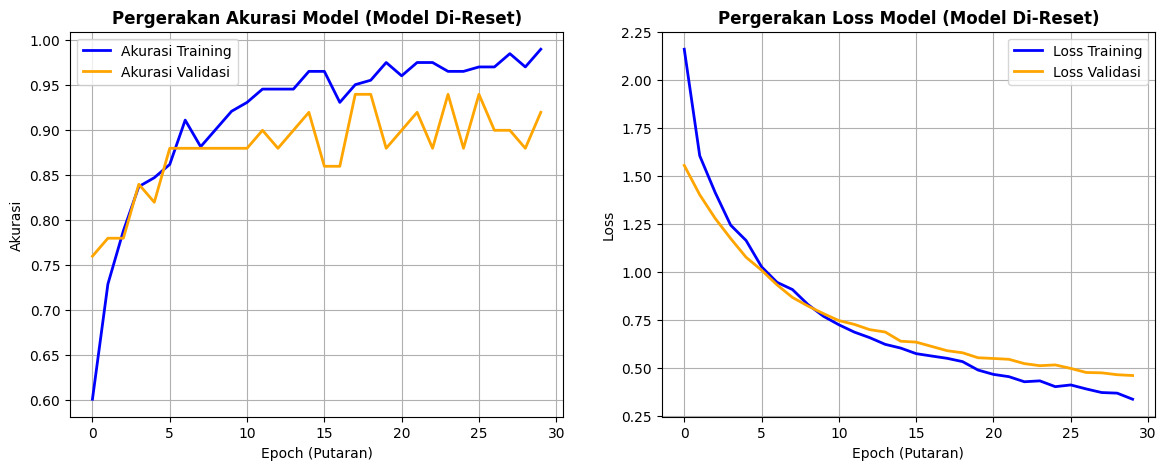

In [9]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_new.history['accuracy'], label='Akurasi Training', color='blue', linewidth=2)
plt.plot(history_new.history['val_accuracy'], label='Akurasi Validasi', color='orange', linewidth=2)
plt.title('Pergerakan Akurasi Model (Model Di-Reset)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch (Putaran)')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_new.history['loss'], label='Loss Training', color='blue', linewidth=2)
plt.plot(history_new.history['val_loss'], label='Loss Validasi', color='orange', linewidth=2)
plt.title('Pergerakan Loss Model (Model Di-Reset)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch (Putaran)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

Model sedang menganalisis data validasi...
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step


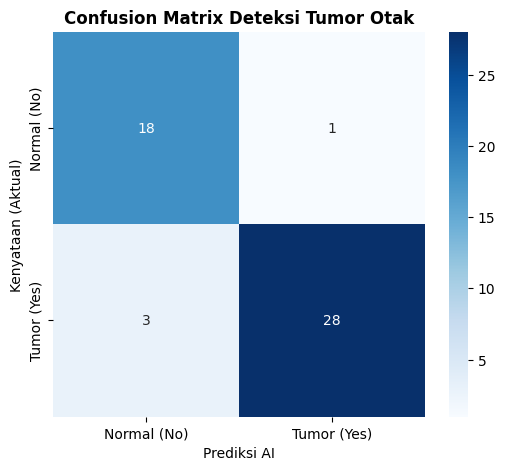


--- Laporan Klasifikasi Detail ---
              precision    recall  f1-score   support

 Normal (No)       0.86      0.95      0.90        19
 Tumor (Yes)       0.97      0.90      0.93        31

    accuracy                           0.92        50
   macro avg       0.91      0.93      0.92        50
weighted avg       0.92      0.92      0.92        50



In [10]:
import seaborn as sns
val_generator.reset()

# AI mulai memprediksi seluruh data validasi
print("Model sedang menganalisis data validasi...")
predictions = model.predict(val_generator)

# Mengubah nilai desimal sigmoid (0-1) menjadi kelas biner (0 atau 1) dengan ambang batas 0.5
y_pred = np.where(predictions > 0.5, 1, 0)
y_true = val_generator.classes

# 1. Membuat Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (No)', 'Tumor (Yes)'],
            yticklabels=['Normal (No)', 'Tumor (Yes)'])
plt.title('Confusion Matrix Deteksi Tumor Otak', fontsize=12, fontweight='bold')
plt.xlabel('Prediksi AI')
plt.ylabel('Kenyataan (Aktual)')
plt.show()

# 2. Menampilkan Laporan Statistik Detail
print("\n--- Laporan Klasifikasi Detail ---")
print(classification_report(y_true, y_pred, target_names=['Normal (No)', 'Tumor (Yes)']))

# Simpan model deep learning

In [11]:
# 1. Simpan arsitektur model sebagai JSON
model_json = model.to_json()
with open("model_klasifikasi_gambar.json", "w") as json_file:
    json_file.write(model_json)
    print("Arsitektur model disimpan ke JSON.")

# 2. Simpan bobot saja ke format .weights.h5 (Format ini sangat stabil)
model.save_weights("model_klasifikasi_gambar.weights.h5")
print("Bobot model disimpan ke .weights.h5")

Arsitektur model disimpan ke JSON.
Bobot model disimpan ke .weights.h5


In [12]:
print(model.summary())
print(model.get_config())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,504,133 (9.55 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 164,100 (641.02 KB)

None
{'name': 'sequential', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 150, 150, 3), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'input_layer_1', 'optional': False}, 'registered_name': None}, {'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {'name': 'mobilenetv2_1.00_224', 'trainable': False, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 150, 150, 3), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'input_layer', 'optional': False}, 'registered_name': None, 'name': 'input_layer', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'Conv2D', 'config': {'name': 'Conv1', 'trainable': False, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'},